# 🚀 Gradient Boosting Regression Tutorial for Turbofan Engine RUL Prediction

## Learning Objectives

By the end of this tutorial, you will:
- Understand what Boosting is and how it differs from Bagging
- Learn about Gradient Boosting algorithm step-by-step
- Understand key hyperparameters (n_estimators, learning_rate, max_depth)
- Learn about loss functions in Gradient Boosting
- Train and evaluate a Gradient Boosting model
- Compare Gradient Boosting with Random Forest and other models
- Visualize predictions and feature importance

---

## What is Boosting?

**Boosting** is an **ensemble learning** technique that combines multiple **weak learners** (simple models) into a **strong learner** (powerful model).

### The Basic Idea:

Imagine learning from your mistakes:
1. Start with a simple model
2. See where it makes mistakes
3. Build a new model that **focuses on those mistakes**
4. Combine all models
5. Repeat until good enough

### Key Difference: Boosting vs Bagging

#### Bagging (Random Forest):
- Models train **independently** (in parallel)
- Each model sees **different random data**
- Models make **different mistakes**
- **Average** predictions (equal weight)
- Example: 100 experts vote independently

#### Boosting (Gradient Boosting):
- Models train **sequentially** (one after another)
- Each model **learns from previous mistakes**
- Models **correct previous errors**
- **Weighted sum** of predictions (later models have more weight)
- Example: Student learns from teacher's corrections

### Visual Comparison:

**Bagging (Random Forest):**
```
Tree 1 ──┐
Tree 2 ──┤
Tree 3 ──┼──> Average ──> Final Prediction
Tree 4 ──┤
Tree 5 ──┘
(All train at the same time)
```

**Boosting (Gradient Boosting):**
```
Tree 1 ──> Errors ──> Tree 2 ──> Errors ──> Tree 3 ──> ... ──> Final Prediction
         (learns from)        (learns from)
(Train one after another)
```

### Why Boosting Works:

1. **Sequential Learning**: Each model fixes previous mistakes
2. **Focus on Hard Examples**: Later models focus on difficult cases
3. **Weighted Combination**: Better models get more influence
4. **Strong from Weak**: Many weak models → one strong model

---

## What is Gradient Boosting?

**Gradient Boosting** is a specific boosting algorithm that:
- Uses **gradient descent** to minimize loss
- Builds trees **sequentially**
- Each tree **predicts the errors** of previous trees
- Combines all trees with a **learning rate**

### How Gradient Boosting Works (Step-by-Step):

#### Step 1: Start with Initial Prediction
```
Initial prediction = mean(y)  (or median)
Example: All engines have RUL = 100 cycles (average)
```

#### Step 2: Calculate Residuals (Errors)
```
Residuals = Actual - Predicted
Example:
  Engine 1: Actual=150, Predicted=100 → Residual=50
  Engine 2: Actual=80, Predicted=100 → Residual=-20
  Engine 3: Actual=120, Predicted=100 → Residual=20
```

#### Step 3: Train Tree on Residuals
```
Tree 1 learns to predict residuals:
  - If T30 > 1500 → predict +30 (add 30 cycles)
  - If T30 ≤ 1500 → predict -10 (subtract 10 cycles)
```

#### Step 4: Update Predictions
```
New prediction = Old prediction + (learning_rate × Tree1_prediction)

Example (learning_rate = 0.1):
  Engine 1: 100 + 0.1 × 30 = 103
  Engine 2: 100 + 0.1 × (-10) = 99
  Engine 3: 100 + 0.1 × 20 = 102
```

#### Step 5: Repeat
```
Calculate new residuals
Train Tree 2 on new residuals
Update predictions again
Repeat for Tree 3, 4, 5, ... up to n_estimators
```

#### Final Prediction:
```
Final = Initial + lr×Tree1 + lr×Tree2 + lr×Tree3 + ... + lr×TreeN
```

### Key Concepts:

#### 1. Learning Rate (Shrinkage):
- Controls how much each tree contributes
- **Small learning rate** (e.g., 0.01, 0.1):
  - Small steps
  - More trees needed
  - Less overfitting
  - Better generalization

- **Large learning rate** (e.g., 0.5, 1.0):
  - Large steps
  - Fewer trees needed
  - More overfitting risk
  - Faster training

**Default**: learning_rate=0.1

#### 2. Number of Estimators (Trees):
- How many trees to build sequentially
- **More trees** = better accuracy (up to a point)
- **Too many trees** = overfitting
- **Trade-off**: More trees + smaller learning rate = better

**Default**: n_estimators=100

#### 3. Loss Function:
- Measures prediction error
- **'squared_error'** (Least Squares): For regression (default, was 'ls' in older versions)
- **'absolute_error'** (Least Absolute Deviation): Robust to outliers (was 'lad' in older versions)
- **'huber'**: Combination of squared_error and absolute_error
- **'quantile'**: For quantile regression

### Advantages of Gradient Boosting:

✅ **Very accurate**: Often best performance
✅ **Handles non-linear relationships**: Automatically
✅ **Feature importance**: Like Random Forest
✅ **No scaling needed**: Works with raw features
✅ **Flexible**: Many hyperparameters to tune

### Disadvantages:

❌ **Slow training**: Sequential (can't parallelize easily)
❌ **Overfitting risk**: If not tuned properly
❌ **Many hyperparameters**: Hard to tune
❌ **Less interpretable**: Complex model
❌ **Memory intensive**: Stores all trees

### Gradient Boosting vs Random Forest:

| Aspect | Random Forest | Gradient Boosting |
|--------|---------------|-------------------|
| **Training** | Parallel (fast) | Sequential (slow) |
| **Learning** | Independent | Sequential (learns from errors) |
| **Accuracy** | Very good | Often better |
| **Overfitting** | Less risk | More risk |
| **Hyperparameters** | Fewer | More |
| **Default performance** | Excellent | Excellent |

---

## Our Goal: Predict RUL (Remaining Useful Life)

We want to predict **how many cycles** an engine has left before it fails, using Gradient Boosting.

Gradient Boosting is excellent for this because:
- Can achieve very high accuracy
- Handles complex, non-linear relationships
- Automatically finds feature importance
- Can capture subtle patterns in sensor data

## Step 1: Import Required Libraries

Before we start, we need to import the necessary libraries.

### Libraries We'll Use:
- **pandas**: For DataFrames and data manipulation
- **numpy**: For numerical operations
- **matplotlib & seaborn**: For visualizations
- **sklearn**: Scikit-learn - the main machine learning library
  - `GradientBoostingRegressor`: Our Gradient Boosting model
  - `train_test_split`: To split data into training and validation sets
  - `mean_squared_error`, `mean_absolute_error`, `r2_score`: For evaluation metrics

In [17]:
# Import libraries for data handling
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
import time  # To measure training time

# Import machine learning components from scikit-learn
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set visualization style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('ggplot')

sns.set_palette("husl")
%matplotlib inline

print("✅ All libraries imported successfully!")
print(f"📦 Pandas version: {pd.__version__}")
print(f"📦 NumPy version: {np.__version__}")
print(f"📦 Scikit-learn version: {__import__('sklearn').__version__}")

✅ All libraries imported successfully!
📦 Pandas version: 2.3.2
📦 NumPy version: 2.2.6
📦 Scikit-learn version: 1.7.2


## Step 2: Load the Dataset

Let's load our turbofan engine dataset. Gradient Boosting doesn't require feature scaling, but we'll still prepare the data properly.

In [18]:
# Define the path to our dataset
data_path = Path('dataset/6.+Turbofan+Engine+Degradation+Simulation+Data+Set/6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData')

# Column names
op_settings = ['Altitude', 'Mach', 'TRA']
sensors = ['T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30', 'Nf', 'Nc', 'epr', 'Ps30', 'phi', 
           'NRf', 'NRc', 'BPR', 'farB', 'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32']
column_names = ['unit', 'time'] + op_settings + sensors

def load_data(dataset='FD001'):
    """Load training and test data from CSV files"""
    train_file = data_path / f'train_{dataset}.csv'
    test_file = data_path / f'test_{dataset}.csv'
    rul_file = data_path / f'RUL_{dataset}.csv'
    
    # Read CSV files (they already have headers)
    train_df = pd.read_csv(train_file)
    test_df = pd.read_csv(test_file)
    rul_df = pd.read_csv(rul_file)
    
    return train_df, test_df, rul_df

def calculate_rul_train(df):
    """Calculate RUL (Remaining Useful Life) for training data"""
    df = df.copy()
    df['RUL'] = df.groupby('unit')['time'].transform(lambda x: x.max() - x)
    return df

# Load data for FD001 dataset
train_df, test_df, rul_df = load_data('FD001')

# Calculate RUL for training data
train_df = calculate_rul_train(train_df)

print("✅ Data loaded successfully!")
print(f"\n📊 Training data shape: {train_df.shape}")
print(f"📊 Test data shape: {test_df.shape}")
print(f"🚁 Number of engines in training: {train_df['unit'].nunique()}")
print(f"🚁 Number of engines in test: {test_df['unit'].nunique()}")

✅ Data loaded successfully!

📊 Training data shape: (20631, 27)
📊 Test data shape: (13096, 26)
🚁 Number of engines in training: 100
🚁 Number of engines in test: 100


## Step 3: Prepare Features and Target

Gradient Boosting doesn't require feature scaling, but we still need to prepare features and target properly.

In [19]:
# Select features (X) - everything except unit and RUL
feature_columns = op_settings + sensors + ['time']

# Prepare training features (X) and target (y)
X_train = train_df[feature_columns].copy()
y_train = train_df['RUL'].copy()

# Prepare test data - get last timestep for each engine
test_last_indices = test_df.groupby('unit')['time'].idxmax().values
X_test = test_df.loc[test_last_indices, feature_columns].reset_index(drop=True)
y_test = rul_df['RUL'].values

print("✅ Features and target prepared!")
print(f"\n📊 Training Features shape: {X_train.shape}")
print(f"   - Number of samples: {X_train.shape[0]:,}")
print(f"   - Number of features: {X_train.shape[1]}")
print(f"\n📊 Test Features shape: {X_test.shape}")
print(f"\n💡 Note: Gradient Boosting doesn't require feature scaling!")

✅ Features and target prepared!

📊 Training Features shape: (20631, 25)
   - Number of samples: 20,631
   - Number of features: 25

📊 Test Features shape: (100, 25)

💡 Note: Gradient Boosting doesn't require feature scaling!


In [20]:
# Split training data into train and validation sets
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train, 
    test_size=0.2, 
    random_state=42
)

print("✅ Data split successfully!")
print(f"\n📊 Training set: {X_train_split.shape[0]:,} samples")
print(f"📊 Validation set: {X_val_split.shape[0]:,} samples")
print(f"📊 Test set: {X_test.shape[0]} samples")

✅ Data split successfully!

📊 Training set: 16,504 samples
📊 Validation set: 4,127 samples
📊 Test set: 100 samples


## Step 4: Understanding Gradient Boosting Hyperparameters

Gradient Boosting has several important hyperparameters. Understanding these is crucial for good performance!

### Key Hyperparameters:

#### 1. **n_estimators** - Number of Trees

**What it does**: How many trees to build sequentially

**Values**:
- **Small** (e.g., 50, 100):
  - Faster training
  - May underfit
  - Need larger learning rate

- **Large** (e.g., 200, 500, 1000):
  - Slower training
  - Better accuracy (up to a point)
  - Can overfit if learning rate too high
  - Works well with small learning rate

**Default**: n_estimators=100

**Rule of thumb**: More trees + smaller learning rate = better

#### 2. **learning_rate** - Shrinkage Factor

**What it does**: Controls contribution of each tree

**Values**:
- **Small** (e.g., 0.01, 0.05, 0.1):
  - Small steps
  - More trees needed
  - Less overfitting
  - Better generalization
  - **Recommended for best performance**

- **Large** (e.g., 0.5, 1.0):
  - Large steps
  - Fewer trees needed
  - More overfitting risk
  - Faster training

**Default**: learning_rate=0.1

**Important**: learning_rate × n_estimators should be balanced
- High LR + Many trees = Overfitting
- Low LR + Few trees = Underfitting
- Low LR + Many trees = Best (but slow)

#### 3. **max_depth** - Maximum Tree Depth

**What it does**: Maximum depth of each tree

**Values**:
- **Small** (e.g., 3, 5):
  - Simple trees
  - Less overfitting
  - More trees needed
  - **Recommended** (3-5 is common)

- **Large** (e.g., 10, 20):
  - Complex trees
  - More overfitting risk
  - Fewer trees needed

**Default**: max_depth=3

**Rule of thumb**: Shallow trees (3-5) work best with boosting

#### 4. **min_samples_split** - Minimum Samples to Split

**What it does**: Minimum samples required to split a node

**Values**:
- **Small** (e.g., 2, 5):
  - More splits
  - More complex trees
  - More overfitting risk

- **Large** (e.g., 20, 50):
  - Fewer splits
  - Simpler trees
  - Less overfitting

**Default**: min_samples_split=2

#### 5. **min_samples_leaf** - Minimum Samples in Leaf

**What it does**: Minimum samples required in a leaf node

**Values**:
- **Small** (e.g., 1, 5):
  - Smaller leaves
  - More detailed splits
  - More overfitting risk

- **Large** (e.g., 10, 20):
  - Larger leaves
  - Smoother predictions
  - Less overfitting

**Default**: min_samples_leaf=1

#### 6. **subsample** - Row Sampling

**What it does**: Fraction of samples to use for each tree

**Values**:
- **1.0**: Use all data (default)
- **< 1.0** (e.g., 0.8, 0.9):
  - Use random subset
  - More randomness
  - Less overfitting
  - Similar to Random Forest

**Default**: subsample=1.0

#### 7. **loss** - Loss Function

**What it does**: Function to minimize during training

**Options**:
- **'squared_error'** (Least Squares): Default for regression (was 'ls' in older versions)
- **'absolute_error'** (Least Absolute Deviation): Robust to outliers (was 'lad' in older versions)
- **'huber'**: Combination of squared_error and absolute_error
- **'quantile'**: For quantile regression

**Default**: loss='squared_error'

**Note**: In scikit-learn 1.2+, parameter names changed:
- 'ls' → 'squared_error'
- 'lad' → 'absolute_error'

### Summary Table:

| Hyperparameter | Low Value | High Value | Effect |
|---------------|-----------|------------|--------|
| **n_estimators** | Few trees, fast | Many trees, accurate | Number of models |
| **learning_rate** | Small steps, many trees | Large steps, few trees | Step size |
| **max_depth** | Simple trees | Complex trees | Tree complexity |
| **min_samples_split** | More splits | Fewer splits | Overfitting control |
| **subsample** | More random | Less random | Overfitting control |

### Important Relationships:

1. **learning_rate × n_estimators**:
   - Keep product roughly constant
   - Low LR (0.01) + Many trees (500) = Best
   - High LR (0.5) + Few trees (50) = Fast but risky

2. **max_depth + n_estimators**:
   - Shallow trees (3-5) + Many trees = Best
   - Deep trees (10+) + Many trees = Overfitting

3. **subsample + learning_rate**:
   - subsample < 1.0 adds randomness
   - Helps prevent overfitting
   - Can use higher learning rate

### How to Choose Hyperparameters?

1. **Start with defaults**: Usually work well!
2. **Increase n_estimators**: If you have time
3. **Decrease learning_rate**: Better generalization (but need more trees)
4. **Keep max_depth small**: 3-5 is usually best
5. **Use subsample < 1.0**: If overfitting
6. **Use GridSearchCV**: Automatically find best combination

## Step 5: Understanding Loss Functions in Gradient Boosting

Gradient Boosting minimizes a **loss function** during training. Let's understand the options.

### Available Loss Functions:

#### 1. **'squared_error' (Least Squares)** - Default

**Note**: In scikit-learn 1.2+, this was renamed from 'ls' to 'squared_error'

**Formula**: `Loss = (1/n) × Σ(actual - predicted)²`

**Characteristics**:
- Same as MSE (Mean Squared Error)
- Penalizes large errors heavily (squared)
- Sensitive to outliers
- Good for most regression problems

**When to use**: Default choice, works well for most cases

#### 2. **'absolute_error' (Least Absolute Deviation)**

**Note**: In scikit-learn 1.2+, this was renamed from 'lad' to 'absolute_error'

**Formula**: `Loss = (1/n) × Σ|actual - predicted|`

**Characteristics**:
- Same as MAE (Mean Absolute Error)
- Treats all errors equally (not squared)
- Robust to outliers
- Less sensitive than 'squared_error'

**When to use**: When you have outliers or want robust predictions

#### 3. **'huber'**

**Formula**: Combines 'squared_error' for small errors and 'absolute_error' for large errors

**Characteristics**:
- Best of both worlds
- Less sensitive to outliers than 'squared_error'
- More sensitive to small errors than 'absolute_error'
- Requires **alpha** parameter (threshold)

**When to use**: When you want balance between 'squared_error' and 'absolute_error'

#### 4. **'quantile'**

**Formula**: Predicts specific quantiles (e.g., median, 90th percentile)

**Characteristics**:
- Useful for uncertainty estimation
- Requires **alpha** parameter (quantile level, 0-1)
- alpha=0.5 = median (same as 'absolute_error')

**When to use**: When you need quantile predictions

### Visual Comparison:

Let's visualize how different loss functions penalize errors.

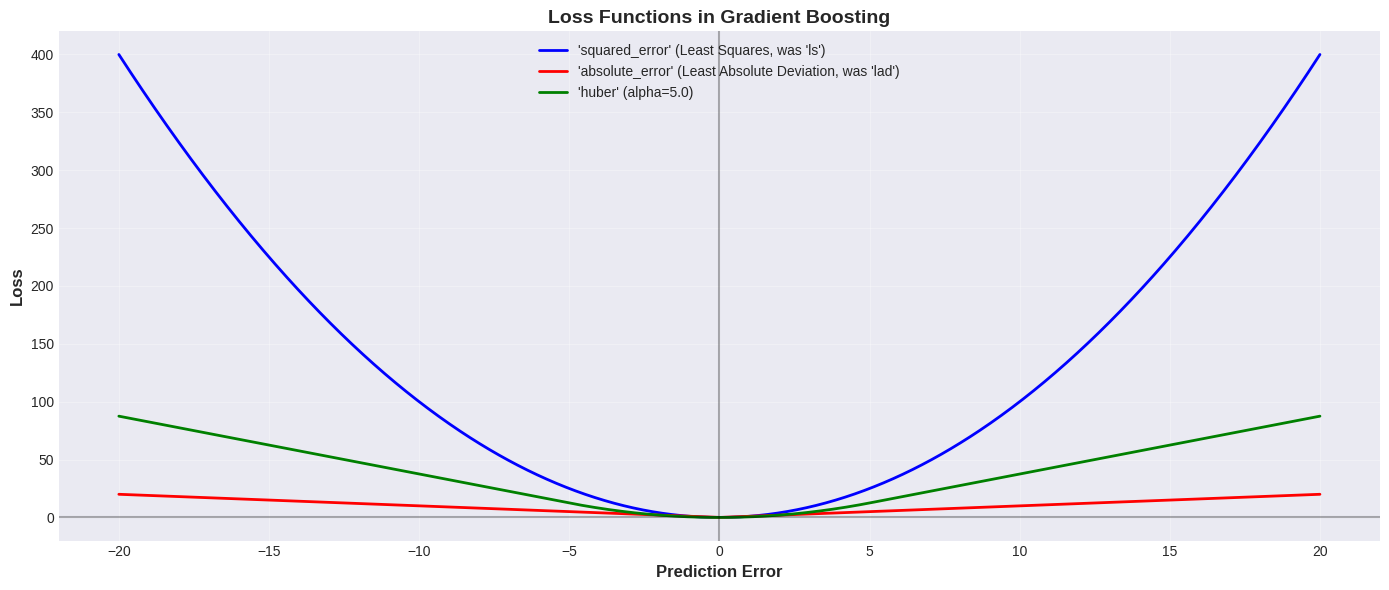

✅ Loss function visualization created!

💡 Key Observations:
   - 'squared_error' (blue): Squared errors - heavily penalizes large errors
   - 'absolute_error' (red): Absolute errors - treats all errors equally
   - 'huber' (green): Combines both - less sensitive to outliers than 'squared_error'


In [21]:
# Visualize different loss functions
errors = np.linspace(-20, 20, 1000)

# Calculate different losses
ls_loss = errors ** 2  # Least squares
lad_loss = np.abs(errors)  # Least absolute deviation
huber_alpha = 5.0
huber_loss = np.where(np.abs(errors) <= huber_alpha, 
                      0.5 * errors ** 2, 
                      huber_alpha * (np.abs(errors) - 0.5 * huber_alpha))

# Plot comparison
plt.figure(figsize=(14, 6))

plt.plot(errors, ls_loss, 'b-', linewidth=2, label="'squared_error' (Least Squares, was 'ls')")
plt.plot(errors, lad_loss, 'r-', linewidth=2, label="'absolute_error' (Least Absolute Deviation, was 'lad')")
plt.plot(errors, huber_loss, 'g-', linewidth=2, label=f"'huber' (alpha={huber_alpha})")

plt.xlabel('Prediction Error', fontsize=12, fontweight='bold')
plt.ylabel('Loss', fontsize=12, fontweight='bold')
plt.title('Loss Functions in Gradient Boosting', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Loss function visualization created!")
print("\n💡 Key Observations:")
print("   - 'squared_error' (blue): Squared errors - heavily penalizes large errors")
print("   - 'absolute_error' (red): Absolute errors - treats all errors equally")
print("   - 'huber' (green): Combines both - less sensitive to outliers than 'squared_error'")

## Step 6: Create and Train Gradient Boosting Model

Let's create a Gradient Boosting model. We'll start with default parameters, then tune them.

In [22]:
# Create Gradient Boosting model with default parameters
print("🚀 Creating Gradient Boosting model...")
print("=" * 80)

# Default Gradient Boosting
# n_estimators=100: 100 trees
# learning_rate=0.1: Each tree contributes 10%
# max_depth=3: Shallow trees (good for boosting)
# loss='squared_error': Least squares loss (was 'ls' in older versions)
# random_state=42: For reproducibility
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=1,
    subsample=1.0,
    loss='squared_error',  # 'squared_error' (new) or 'ls' (old)
    random_state=42
)

print("✅ Model created!")
print(f"\n📝 Model parameters:")
print(f"   Number of trees: {gb_model.n_estimators}")
print(f"   Learning rate: {gb_model.learning_rate}")
print(f"   Max depth: {gb_model.max_depth}")
print(f"   Loss function: {gb_model.loss}")
print(f"   Subsample: {gb_model.subsample}")

🚀 Creating Gradient Boosting model...
✅ Model created!

📝 Model parameters:
   Number of trees: 100
   Learning rate: 0.1
   Max depth: 3
   Loss function: squared_error
   Subsample: 1.0


In [23]:
# Train the model
print("\n🚀 Training Gradient Boosting model...")
print("⚠️  This may take a few minutes (sequential training)...")
print("=" * 80)

start_time = time.time()
gb_model.fit(X_train_split, y_train_split)
training_time = time.time() - start_time

print(f"\n✅ Model trained successfully in {training_time:.2f} seconds ({training_time/60:.1f} minutes)!")
print(f"\n📊 Model Information:")
print(f"   Number of trees: {gb_model.n_estimators}")
print(f"   Total features: {gb_model.n_features_in_}")
# Extract initial prediction value (convert numpy scalar to Python float)
initial_pred = float(gb_model.init_.constant_[0])
print(f"   Initial prediction (mean): {initial_pred:.2f} cycles")


🚀 Training Gradient Boosting model...
⚠️  This may take a few minutes (sequential training)...

✅ Model trained successfully in 3.97 seconds (0.1 minutes)!

📊 Model Information:
   Number of trees: 100
   Total features: 25


TypeError: unsupported format string passed to numpy.ndarray.__format__

## Step 7: Monitor Training Progress (Learning Curves)

Gradient Boosting allows us to monitor training progress. We can see how performance improves with each tree!

📊 Calculating learning curves...


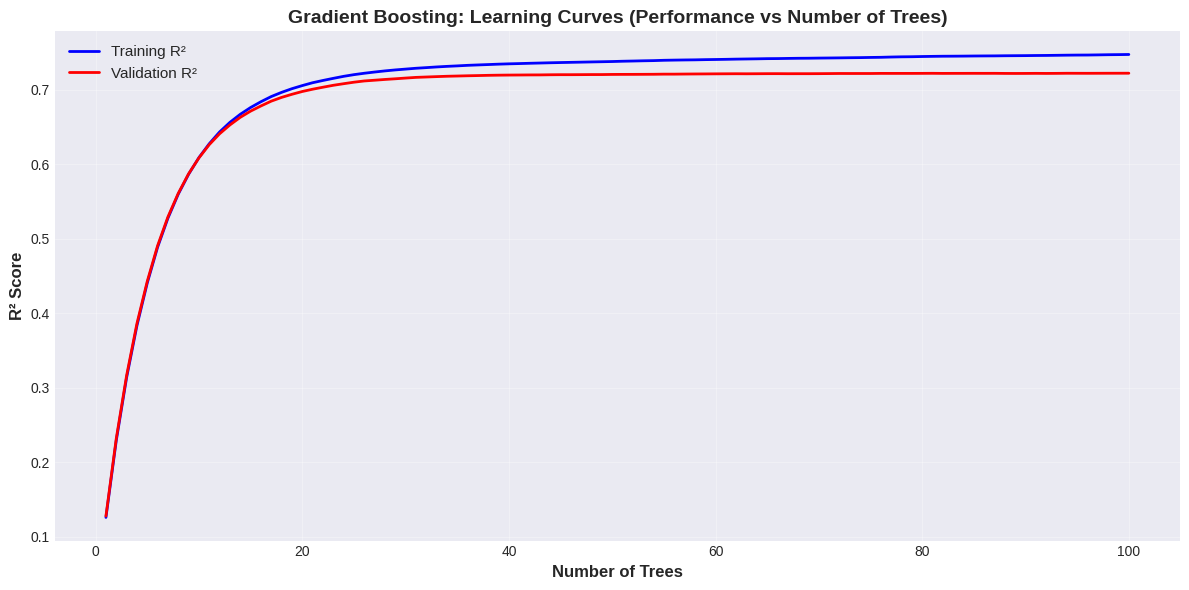

✅ Learning curves created!

📊 Final Scores:
   Training R²: 0.7473
   Validation R²: 0.7221

✅ Good generalization: Train and validation R² are similar


In [24]:
# Check if model is fitted
from sklearn.utils.validation import check_is_fitted
try:
    check_is_fitted(gb_model)
except:
    print("❌ Error: Model is not fitted yet!")
    print("   Please run the previous cell to train the model first.")
    raise

# Get training progress (staged predictions)
# This shows how predictions improve with each tree
train_scores = []
val_scores = []

print("📊 Calculating learning curves...")

# Calculate R² for each stage (each tree added)
for i, y_pred in enumerate(gb_model.staged_predict(X_train_split), 1):
    train_scores.append(r2_score(y_train_split, y_pred))

for i, y_pred in enumerate(gb_model.staged_predict(X_val_split), 1):
    val_scores.append(r2_score(y_val_split, y_pred))

# Visualize learning curves
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(train_scores) + 1), train_scores, 'b-', linewidth=2, label='Training R²')
plt.plot(range(1, len(val_scores) + 1), val_scores, 'r-', linewidth=2, label='Validation R²')
plt.xlabel('Number of Trees', fontsize=12, fontweight='bold')
plt.ylabel('R² Score', fontsize=12, fontweight='bold')
plt.title('Gradient Boosting: Learning Curves (Performance vs Number of Trees)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Learning curves created!")
print(f"\n📊 Final Scores:")
print(f"   Training R²: {train_scores[-1]:.4f}")
print(f"   Validation R²: {val_scores[-1]:.4f}")

# Check for overfitting
if train_scores[-1] - val_scores[-1] > 0.1:
    print(f"\n⚠️  Warning: Large gap suggests overfitting!")
    print("   Consider: reducing learning_rate, increasing n_estimators, or reducing max_depth")
else:
    print(f"\n✅ Good generalization: Train and validation R² are similar")

## Step 8: Feature Importance

Like Random Forest, Gradient Boosting also provides feature importance!

In [25]:
# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("📊 Feature Importance (Top 15):")
print("=" * 80)
print(feature_importance.head(15).to_string(index=False))

print(f"\n💡 Total importance: {feature_importance['Importance'].sum():.4f}")
print(f"   (Should be close to 1.0)")

📊 Feature Importance (Top 15):
Feature  Importance
   time    0.672149
   Ps30    0.092951
    T50    0.074889
    phi    0.036512
     Nc    0.029028
    P30    0.026706
    BPR    0.013539
    W32    0.011853
    NRc    0.010101
    T24    0.009461
    W31    0.008163
     Nf    0.004681
    NRf    0.002805
    T30    0.002782
htBleed    0.002615

💡 Total importance: 1.0000
   (Should be close to 1.0)


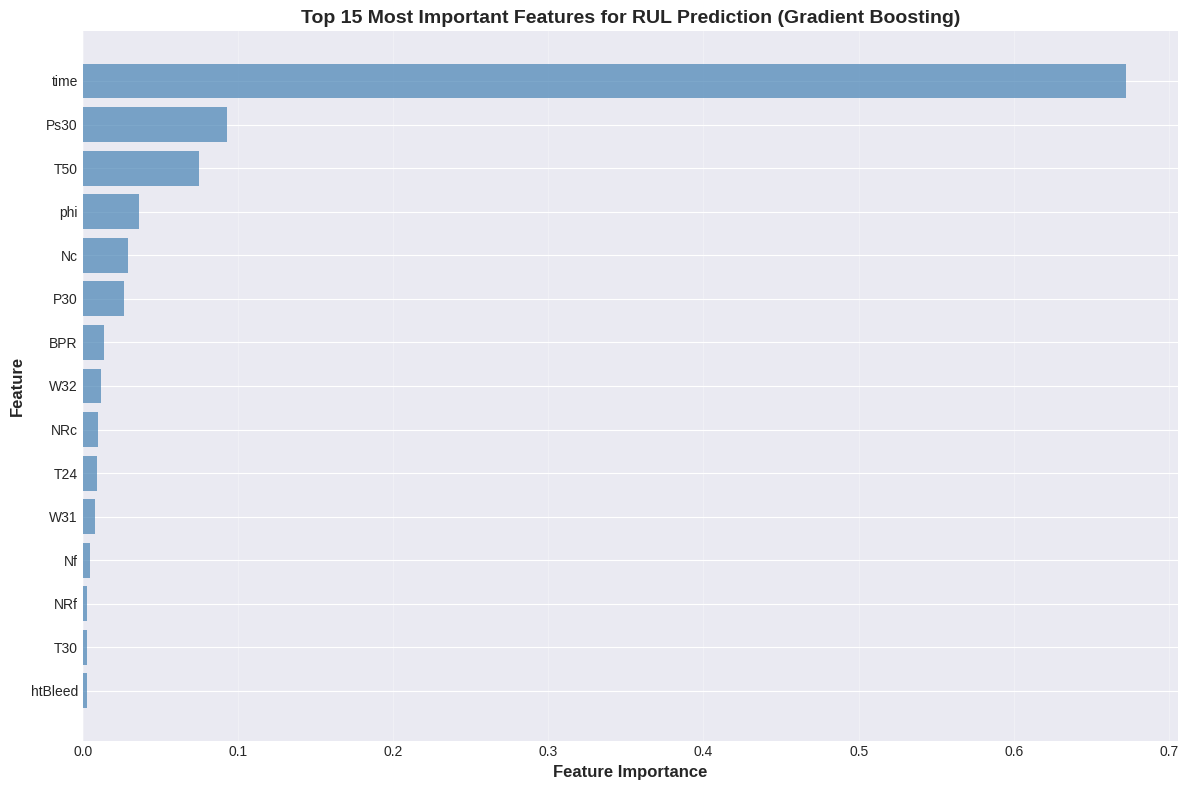

✅ Feature importance visualization created!


In [26]:
# Visualize feature importance
plt.figure(figsize=(12, 8))

# Get top 15 features
top_features = feature_importance.head(15)

plt.barh(range(len(top_features)), top_features['Importance'], color='steelblue', alpha=0.7)
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Feature Importance', fontsize=12, fontweight='bold')
plt.ylabel('Feature', fontsize=12, fontweight='bold')
plt.title('Top 15 Most Important Features for RUL Prediction (Gradient Boosting)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Show most important at top
plt.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("✅ Feature importance visualization created!")

## Step 9: Make Predictions

Now let's use the trained model to make predictions!

In [27]:
# Make predictions on all datasets
print("🔮 Making predictions...")

# Training set predictions
y_train_pred = gb_model.predict(X_train_split)

# Validation set predictions
y_val_pred = gb_model.predict(X_val_split)

# Test set predictions
y_test_pred = gb_model.predict(X_test)

print("✅ Predictions made successfully!")
print(f"\n📊 Sample predictions (first 5 test samples):")
print(f"   Actual RUL:    {y_test[:5]}")
print(f"   Predicted RUL: {y_test_pred[:5].round(2)}")
print(f"   Errors:        {(y_test[:5] - y_test_pred[:5]).round(2)}")

🔮 Making predictions...
✅ Predictions made successfully!

📊 Sample predictions (first 5 test samples):
   Actual RUL:    [112  98  69  82  91]
   Predicted RUL: [174.84 145.38  51.48  82.77  92.45]
   Errors:        [-62.84 -47.38  17.52  -0.77  -1.45]


## Step 10: Evaluate Model Performance

Let's calculate performance metrics and see how well our Gradient Boosting model performs.

In [28]:
# Calculate metrics
def calculate_metrics(y_true, y_pred, set_name):
    """Calculate RMSE, MAE, and R² score"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'R²': r2}

# Calculate metrics for all sets
train_metrics = calculate_metrics(y_train_split, y_train_pred, 'Train')
val_metrics = calculate_metrics(y_val_split, y_val_pred, 'Val')
test_metrics = calculate_metrics(y_test, y_test_pred, 'Test')

# Display results
print("📊 Gradient Boosting Model Performance")
print("=" * 80)
print(f"\n{'Set':<12} {'RMSE':<12} {'MAE':<12} {'R²':<12}")
print("-" * 80)
print(f"{'Training':<12} {train_metrics['RMSE']:<12.2f} {train_metrics['MAE']:<12.2f} {train_metrics['R²']:<12.4f}")
print(f"{'Validation':<12} {val_metrics['RMSE']:<12.2f} {val_metrics['MAE']:<12.2f} {val_metrics['R²']:<12.4f}")
print(f"{'Test':<12} {test_metrics['RMSE']:<12.2f} {test_metrics['MAE']:<12.2f} {test_metrics['R²']:<12.4f}")

print("\n💡 Interpretation:")
print(f"   - RMSE: On average, predictions are off by ~{test_metrics['RMSE']:.1f} cycles")
print(f"   - MAE: Average absolute error is ~{test_metrics['MAE']:.1f} cycles")
if test_metrics['R²'] > 0.7:
    print(f"   - R²: Model explains {test_metrics['R²']*100:.1f}% of variance (Excellent!)")
elif test_metrics['R²'] > 0.5:
    print(f"   - R²: Model explains {test_metrics['R²']*100:.1f}% of variance (Good)")
else:
    print(f"   - R²: Model explains {test_metrics['R²']*100:.1f}% of variance (Needs improvement)")

# Check for overfitting
train_val_gap = train_metrics['R²'] - val_metrics['R²']
if train_val_gap > 0.1:
    print(f"\n⚠️  Warning: Large gap between train ({train_metrics['R²']:.4f}) and val ({val_metrics['R²']:.4f}) R²")
    print("   This suggests overfitting. Consider:")
    print("   - Reducing learning_rate and increasing n_estimators")
    print("   - Reducing max_depth")
    print("   - Using subsample < 1.0")
else:
    print(f"\n✅ Good generalization: Train and validation R² are similar (gap = {train_val_gap:.4f})")

📊 Gradient Boosting Model Performance

Set          RMSE         MAE          R²          
--------------------------------------------------------------------------------
Training     34.79        24.57        0.7473      
Validation   35.63        25.51        0.7221      
Test         25.24        18.30        0.6312      

💡 Interpretation:
   - RMSE: On average, predictions are off by ~25.2 cycles
   - MAE: Average absolute error is ~18.3 cycles
   - R²: Model explains 63.1% of variance (Good)

✅ Good generalization: Train and validation R² are similar (gap = 0.0251)


## Step 11: Visualize Predictions

Let's create visualizations to see how well the model predicts RUL.

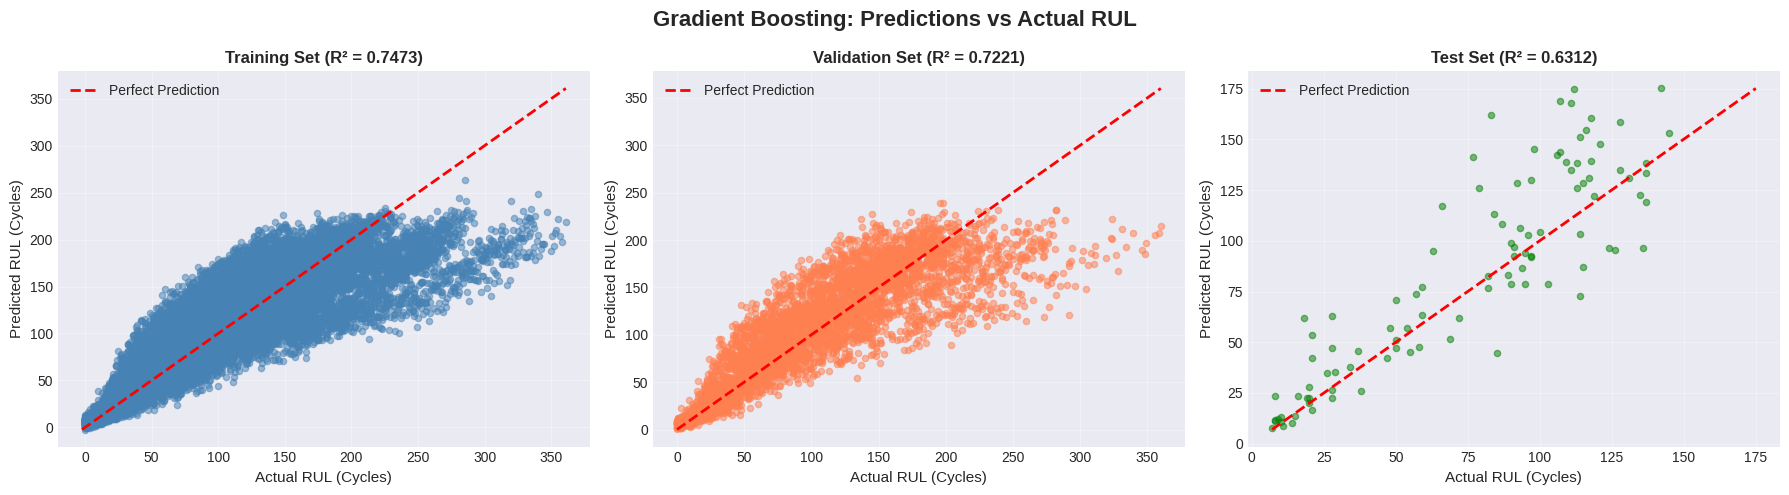

✅ Predictions visualization created!


In [29]:
# Create visualization: Predicted vs Actual
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Gradient Boosting: Predictions vs Actual RUL', fontsize=16, fontweight='bold')

# Training set
axes[0].scatter(y_train_split, y_train_pred, alpha=0.5, s=20, color='steelblue')
min_val = min(min(y_train_split), min(y_train_pred))
max_val = max(max(y_train_split), max(y_train_pred))
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual RUL (Cycles)', fontsize=11)
axes[0].set_ylabel('Predicted RUL (Cycles)', fontsize=11)
axes[0].set_title(f'Training Set (R² = {train_metrics["R²"]:.4f})', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation set
axes[1].scatter(y_val_split, y_val_pred, alpha=0.5, s=20, color='coral')
min_val = min(min(y_val_split), min(y_val_pred))
max_val = max(max(y_val_split), max(y_val_pred))
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual RUL (Cycles)', fontsize=11)
axes[1].set_ylabel('Predicted RUL (Cycles)', fontsize=11)
axes[1].set_title(f'Validation Set (R² = {val_metrics["R²"]:.4f})', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Test set
axes[2].scatter(y_test, y_test_pred, alpha=0.5, s=20, color='green')
min_val = min(min(y_test), min(y_test_pred))
max_val = max(max(y_test), max(y_test_pred))
axes[2].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[2].set_xlabel('Actual RUL (Cycles)', fontsize=11)
axes[2].set_ylabel('Predicted RUL (Cycles)', fontsize=11)
axes[2].set_title(f'Test Set (R² = {test_metrics["R²"]:.4f})', fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Predictions visualization created!")

## Step 12: Hyperparameter Tuning (Optional)

Let's tune the hyperparameters to improve performance. We'll use GridSearchCV, but with a smaller grid since Gradient Boosting is slower.

In [30]:
# Hyperparameter tuning for Gradient Boosting
print("🔍 Tuning hyperparameters for Gradient Boosting...")
print("⚠️  This may take 10-20 minutes (Gradient Boosting is slower)...")
print("=" * 80)

# Define parameter grid (smaller grid for faster tuning)
param_grid = {
    'n_estimators': [50, 100],  # Fewer options for speed
    'learning_rate': [0.05, 0.1],  # Common values
    'max_depth': [3, 5],  # Shallow trees (good for boosting)
    'min_samples_split': [2, 5]
}

# Create base model
gb_base = GradientBoostingRegressor(random_state=42)

# Perform grid search with cross-validation
print("\n⏳ Running GridSearchCV...")
start_time = time.time()

grid_search = GridSearchCV(
    gb_base, 
    param_grid, 
    cv=3,  # 3-fold cross-validation
    scoring='r2',  # Use R² as the scoring metric
    n_jobs=-1,  # Use all CPU cores
    verbose=1  # Show progress
)

grid_search.fit(X_train_split, y_train_split)

tuning_time = time.time() - start_time

print(f"\n✅ Hyperparameter tuning completed in {tuning_time/60:.1f} minutes!")
print(f"\n🏆 Best Parameters:")
for param, value in grid_search.best_params_.items():
    print(f"   {param}: {value}")

print(f"\n📊 Best Cross-Validation R²: {grid_search.best_score_:.4f}")

🔍 Tuning hyperparameters for Gradient Boosting...
⚠️  This may take 10-20 minutes (Gradient Boosting is slower)...

⏳ Running GridSearchCV...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

✅ Hyperparameter tuning completed in 0.5 minutes!

🏆 Best Parameters:
   learning_rate: 0.05
   max_depth: 5
   min_samples_split: 2
   n_estimators: 100

📊 Best Cross-Validation R²: 0.7272


In [31]:
# Evaluate the tuned model
best_gb = grid_search.best_estimator_

# Make predictions with tuned model
y_test_pred_tuned = best_gb.predict(X_test)

# Calculate metrics
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_tuned))
tuned_mae = mean_absolute_error(y_test, y_test_pred_tuned)
tuned_r2 = r2_score(y_test, y_test_pred_tuned)

print("📊 Tuned Model Performance:")
print("=" * 80)
print(f"   Test RMSE: {tuned_rmse:.2f}")
print(f"   Test MAE: {tuned_mae:.2f}")
print(f"   Test R²: {tuned_r2:.4f}")

print(f"\n📊 Comparison with Default Gradient Boosting:")
print(f"   Default R²: {test_metrics['R²']:.4f}")
print(f"   Tuned R²:   {tuned_r2:.4f}")
improvement = (tuned_r2 - test_metrics['R²']) / test_metrics['R²'] * 100
print(f"   Improvement: {improvement:+.2f}%")

📊 Tuned Model Performance:
   Test RMSE: 25.68
   Test MAE: 18.71
   Test R²: 0.6181

📊 Comparison with Default Gradient Boosting:
   Default R²: 0.6312
   Tuned R²:   0.6181
   Improvement: -2.06%


## 🎓 Summary and Key Takeaways

Congratulations! You've successfully built and evaluated a Gradient Boosting model!

### ✅ What You've Learned:

1. **Boosting Basics**:
   - Sequential learning (one tree after another)
   - Each tree learns from previous mistakes
   - Weighted combination of predictions
   - Different from bagging (Random Forest)

2. **Gradient Boosting Algorithm**:
   - Starts with initial prediction (mean)
   - Calculates residuals (errors)
   - Trains tree on residuals
   - Updates predictions with learning rate
   - Repeats for many trees

3. **Key Hyperparameters**:
   - **n_estimators**: Number of trees
   - **learning_rate**: Step size (smaller = better, but slower)
   - **max_depth**: Tree depth (3-5 is best)
   - **loss**: Loss function ('squared_error', 'absolute_error', 'huber')
   - **subsample**: Row sampling for randomness

4. **Loss Functions**:
   - **'squared_error'**: Least squares (default, sensitive to outliers, was 'ls')
   - **'absolute_error'**: Least absolute deviation (robust, was 'lad')
   - **'huber'**: Combination (balanced)

5. **Advantages**:
   - Very accurate (often best performance)
   - Handles non-linear relationships
   - Feature importance available
   - No scaling needed

### 📚 Key Concepts:

- **Boosting**: Sequential ensemble learning
- **Bagging**: Parallel ensemble learning (Random Forest)
- **Learning Rate**: Controls step size
- **Residuals**: Errors that next tree learns to predict
- **Overfitting**: Model memorizes training data

### 🔄 Gradient Boosting vs Random Forest:

| Aspect | Random Forest | Gradient Boosting |
|--------|---------------|-------------------|
| **Training** | Parallel (fast) | Sequential (slow) |
| **Learning** | Independent | Sequential (learns from errors) |
| **Accuracy** | Very good | Often better |
| **Overfitting** | Less risk | More risk |
| **Hyperparameters** | Fewer | More |
| **Learning Rate** | N/A | Critical |
| **Default Performance** | Excellent | Excellent |

### 🚀 Next Steps:

1. **Try Different Learning Rates**:
   - Low LR (0.01) + Many trees (500) = Best accuracy
   - High LR (0.5) + Few trees (50) = Fast but risky

2. **Experiment with Loss Functions**:
   - Try 'absolute_error' for robustness (was 'lad' in older versions)
   - Try 'huber' for balance
   - Compare performance

3. **Try Advanced Boosting**:
   - XGBoost (extreme gradient boosting)
   - LightGBM (lightweight gradient boosting)
   - CatBoost (categorical boosting)

4. **Compare All Models**:
   - Linear Regression
   - SVR
   - Random Forest
   - Gradient Boosting
   - Which performs best?

### 💡 Remember:

- **Gradient Boosting is often the most accurate** but slowest
- **Learning rate is critical** - smaller is usually better
- **Shallow trees (3-5 depth) work best** with boosting
- **Monitor learning curves** to detect overfitting
- **No scaling needed** - works with raw features

---

**Great job completing this tutorial! 🎉🚀**

## 📝 Practice Exercises

Try these exercises to reinforce your learning:

1. **Experiment with Learning Rate**:
   - Try learning_rate = 0.01, 0.05, 0.1, 0.5
   - Adjust n_estimators to keep product constant
   - Compare performance and training time

2. **Experiment with Loss Functions**:
   - Try 'squared_error', 'absolute_error', 'huber'
   - Compare performance
   - Which works best for your data?

3. **Monitor Overfitting**:
   - Plot learning curves
   - Find optimal number of trees (where validation stops improving)
   - Use early stopping

4. **Compare with Random Forest**:
   - Train both on same data
   - Compare accuracy and training time
   - Which is better for your use case?

5. **Try Subsample**:
   - Use subsample = 0.8, 0.9
   - See if it reduces overfitting
   - Compare with subsample = 1.0

Good luck! 🎯